<a href="https://colab.research.google.com/github/Nandhinimh/DEEPFAKE_DETECTION_USING_CNN/blob/main/CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [40]:
import numpy as np
import pandas as pd
from keras.applications.mobilenet import MobileNet, preprocess_input
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2
from tensorflow.keras.models import Sequential,Model
from tensorflow.keras.layers import Dropout, Dense,BatchNormalization, Flatten, MaxPooling2D
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, Callback
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from keras.layers import Conv2D, Reshape
from keras.utils import Sequence
from keras.backend import epsilon
import tensorflow as tf
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import cv2
from tqdm.notebook import tqdm_notebook as tqdm
import os

In [27]:
uploaded = files.upload()

Saving archive.zip to archive (1).zip


In [29]:
# Extract uploaded file
for fn in uploaded.keys():
    zip_name = fn

dataset_dir = "/content/deepfake_dataset"
with zipfile.ZipFile(zip_name, 'r') as zip_ref:
    zip_ref.extractall(dataset_dir)

print("Dataset extracted successfully at:", dataset_dir)
print("Folders:", os.listdir(dataset_dir))

Dataset extracted successfully at: /content/deepfake_dataset
Folders: ['real_and_fake_face_detection', 'real_and_fake_face']


In [30]:
# Preprocess Dataset
img_size = (128,128)
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    dataset_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='training'
)

val_data = datagen.flow_from_directory(
    dataset_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='validation'
)

Found 3266 images belonging to 2 classes.
Found 816 images belonging to 2 classes.


In [33]:
#MODEL 1: MesoNet
def build_mesoNet():
    model = Sequential([
        Conv2D(8, (3,3), activation='relu', input_shape=(128,128,3)),
        MaxPooling2D(2,2),
        Conv2D(16, (3,3), activation='relu'),
        MaxPooling2D(2,2),
        Conv2D(32, (3,3), activation='relu'),
        MaxPooling2D(2,2),
        Flatten(),
        Dense(64, activation='relu'),
        Dropout(0.4),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

mesonet = build_mesoNet()
history_meso = mesonet.fit(train_data, validation_data=val_data, epochs=10, verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 39s 331ms/step - accuracy: 0.4862 - loss: 0.6989 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 2/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 31s 302ms/step - accuracy: 0.4897 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 3/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 35s 340ms/step - accuracy: 0.4928 - loss: 0.6933 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 4/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 30s 295ms/step - accuracy: 0.5215 - loss: 0.6931 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 5/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 31s 304ms/step - accuracy: 0.5063 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 6/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 31s 297ms/step - accuracy: 0.4795 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 7/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 32s 307ms/step - accuracy: 0.5022 - loss: 0.6932 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 8/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 31s 301ms/step - accuracy: 0.4984 - loss: 0

In [34]:
#MODEL 2: MobileNetV2
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(128,128,3))
base_model.trainable = False  # Freeze base layers

mobilenet = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dropout(0.4),
    Dense(1, activation='sigmoid')
])

mobilenet.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history_mobile = mobilenet.fit(train_data, validation_data=val_data, epochs=10, verbose=1)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 70s 536ms/step - accuracy: 0.5067 - loss: 0.8612 - val_accuracy: 0.5000 - val_loss: 0.7229
Epoch 2/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 30s 295ms/step - accuracy: 0.5019 - loss: 0.7933 - val_accuracy: 0.5000 - val_loss: 0.7239
Epoch 3/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 31s 301ms/step - accuracy: 0.4865 - loss: 0.7654 - val_accuracy: 0.5000 - val_loss: 0.7180
Epoch 4/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 31s 305ms/step - accuracy: 0.4864 - loss: 0.7544 - val_accuracy: 0.5000 - val_loss: 0.7090
Epoch 5/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 31s 302ms/step - accuracy: 0.4882 - loss: 0.7479 - val_accuracy: 0.5000 - val_loss: 0.7043
Epoch 6/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 30s 296ms/step - accuracy: 0.4891 - loss: 0.7403 - val_accuracy: 0.5000 - val_loss: 0.7137
Epoch 7/10
103/103 ━━━━━━━━━━━━━━━━━━━━ 31s 301ms/step - accuracy: 0.4982 - loss: 0.7296 - val_accuracy: 0.5000 - val_loss: 0.7019
Epoch 8/10
103/103 ━━━━━━━━━━━━━━━

In [41]:
#MODEL 3: CNN + SVM Hybrid
# Extract features from MobileNet for SVM
feature_extractor = Model(inputs=base_model.input, outputs=GlobalAveragePooling2D()(base_model.output))

# Prepare features and labels for SVM
train_features, train_labels = [], []
for i in range(len(train_data)):
    x_batch, y_batch = train_data[i]
    feats = feature_extractor.predict(x_batch)
    train_features.append(feats)
    train_labels.append(y_batch)
    if i == 10:  # Limit batches for faster demo (optional)
        break

X_train = np.concatenate(train_features)
y_train = np.concatenate(train_labels)

# Train SVM on extracted CNN features
svm = SVC(kernel='linear', probability=True)
svm.fit(X_train, y_train)

# Evaluate SVM on validation set
val_features, val_labels = [], []
for i in range(len(val_data)):
    x_batch, y_batch = val_data[i]
    feats = feature_extractor.predict(x_batch)
    val_features.append(feats)
    val_labels.append(y_batch)
    if i == 5:
        break

X_val = np.concatenate(val_features)
y_val = np.concatenate(val_labels)
y_pred_svm = svm.predict(X_val)
svm_acc = accuracy_score(y_val, y_pred_svm)
print("\nSVM Accuracy on Validation Data:", round(svm_acc*100,2), "%")
print(classification_report(y_val, y_pred_svm))

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step

SVM Accuracy on Validation Data: 53.65 %
              precision    recall  f1-score   support

         0.0       0.53      0.53      0.53        95
         1.0       0.54      0.55      0.54        97

    accuracy                           0.54       192
   macro avg       0.54      0.54      0.54       192
weighted avg       0.54      0.54      0.5

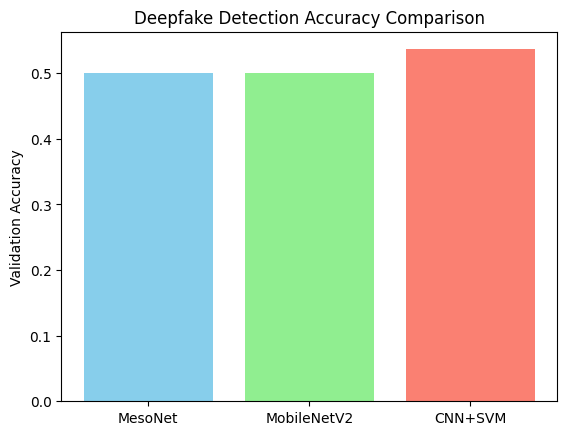

In [42]:
#Compare Model Accuracies
acc = [
    history_meso.history['val_accuracy'][-1],
    history_mobile.history['val_accuracy'][-1],
    svm_acc
]
models = ['MesoNet', 'MobileNetV2', 'CNN+SVM']

plt.bar(models, acc, color=['skyblue','lightgreen','salmon'])
plt.title("Deepfake Detection Accuracy Comparison")
plt.ylabel("Validation Accuracy")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 593ms/step


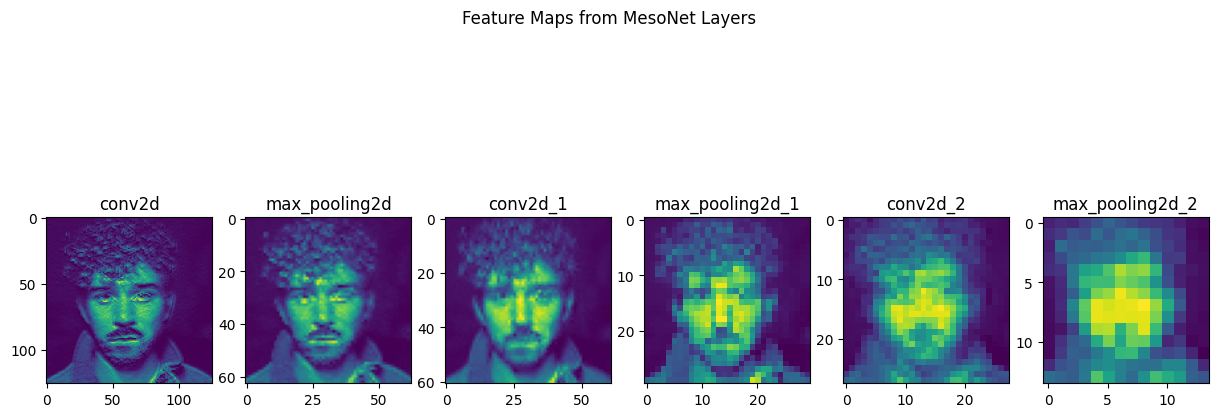

In [46]:
#Visualize Feature Maps (from MesoNet)
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

sample_img, _ = next(train_data)

# Define the input layer explicitly
input_layer = Input(shape=(128, 128, 3))

# Reconstruct the relevant part of the MesoNet model with the defined input layer
x = Conv2D(8, (3,3), activation='relu', name='conv2d')(input_layer)
output_conv1 = x
x = MaxPooling2D(2,2, name='max_pooling2d')(x)
output_pool1 = x
x = Conv2D(16, (3,3), activation='relu', name='conv2d_1')(x)
output_conv2 = x
x = MaxPooling2D(2,2, name='max_pooling2d_1')(x)
output_pool2 = x
x = Conv2D(32, (3,3), activation='relu', name='conv2d_2')(x)
output_conv3 = x
x = MaxPooling2D(2,2, name='max_pooling2d_2')(x)
output_pool3 = x

# Create a new model that takes the input layer and outputs the desired layers
activation_model = Model(inputs=input_layer, outputs=[output_conv1, output_pool1, output_conv2, output_pool2, output_conv3, output_pool3])


activations = activation_model.predict(sample_img[0:1])

layer_names = [layer.name for layer in activation_model.layers if isinstance(layer, (Conv2D, MaxPooling2D))]
plt.figure(figsize=(15, 6))
for i, activation in enumerate(activations):
    plt.subplot(1, len(activations), i + 1)
    plt.imshow(activation[0, :, :, 0], cmap='viridis')
    plt.title(layer_names[i])
plt.suptitle("Feature Maps from MesoNet Layers")
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


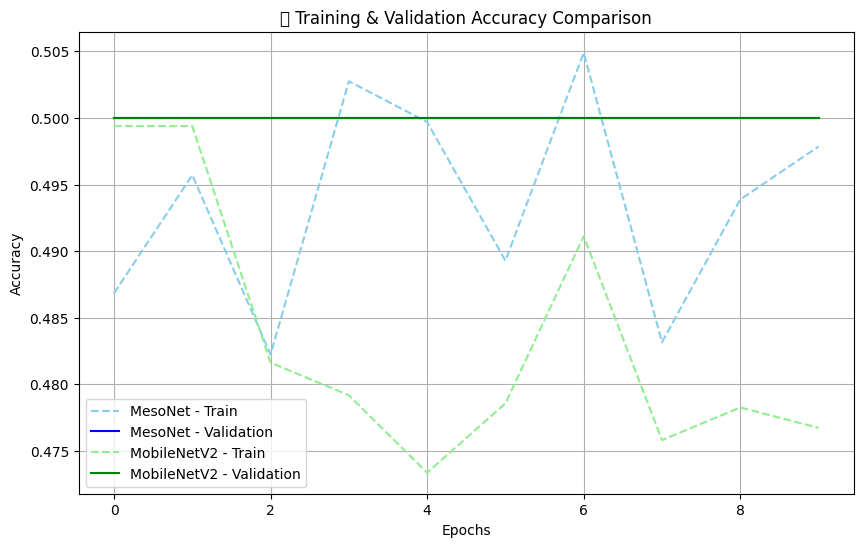

In [47]:
#Comparison Graphs

import matplotlib.pyplot as plt

# 1.Epoch-wise training & validation accuracy for both CNN models
plt.figure(figsize=(10,6))
plt.plot(history_meso.history['accuracy'], label='MesoNet - Train', linestyle='dashed', color='skyblue')
plt.plot(history_meso.history['val_accuracy'], label='MesoNet - Validation', color='blue')
plt.plot(history_mobile.history['accuracy'], label='MobileNetV2 - Train', linestyle='dashed', color='lightgreen')
plt.plot(history_mobile.history['val_accuracy'], label='MobileNetV2 - Validation', color='green')

plt.title('📈 Training & Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


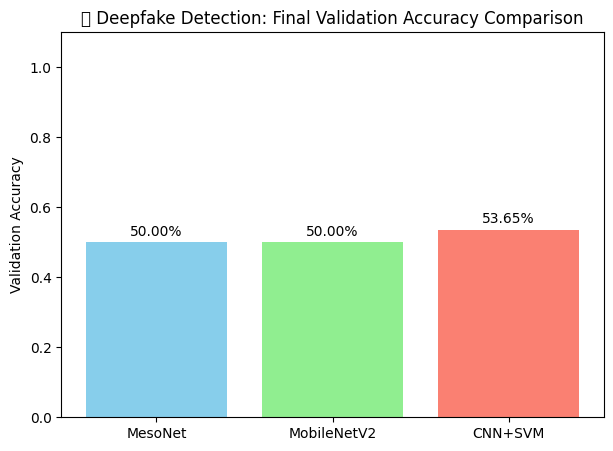

In [48]:
# 2.Final model accuracy comparison (MesoNet, MobileNetV2, CNN+SVM)
acc_meso = history_meso.history['val_accuracy'][-1]
acc_mobile = history_mobile.history['val_accuracy'][-1]
acc_svm = svm_acc

models = ['MesoNet', 'MobileNetV2', 'CNN+SVM']
accuracies = [acc_meso, acc_mobile, acc_svm]

plt.figure(figsize=(7,5))
bars = plt.bar(models, accuracies, color=['skyblue','lightgreen','salmon'])
plt.title("🏆 Deepfake Detection: Final Validation Accuracy Comparison")
plt.ylabel("Validation Accuracy")

# Annotate bars with accuracy values
for bar, acc in zip(bars, accuracies):
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{acc*100:.2f}%", ha='center', va='bottom', fontsize=10)

plt.ylim(0,1.1)
plt.show()



In [49]:
# 3.Print summary
print("\n📋 MODEL PERFORMANCE SUMMARY:")
print(f" - MesoNet Validation Accuracy:    {acc_meso*100:.2f}%")
print(f" - MobileNetV2 Validation Accuracy: {acc_mobile*100:.2f}%")
print(f" - CNN + SVM Accuracy:              {acc_svm*100:.2f}%")

best_model = models[np.argmax(accuracies)]
print(f"\nBest Performing Model: {best_model}")


📋 MODEL PERFORMANCE SUMMARY:
 - MesoNet Validation Accuracy:    50.00%
 - MobileNetV2 Validation Accuracy: 50.00%
 - CNN + SVM Accuracy:              53.65%

Best Performing Model: CNN+SVM
